# Phase 2 — Modeling, Interpretability, and Temporal Dynamics

This notebook extends Phase 2 to support:
- descriptive analysis tables and event-study style summaries
- a **chronological 80/20 train–test split** with an internal validation year
- model comparison across linear and nonlinear methods
- interpretability that follows the **best-performing fitted model**
- lead–lag sensitivity analysis
- municipal, regional, and island-level scenario forecasting

- integration of **islandwide vital-rate context** (birth, death, and natural change signals from Phase 1) into the Phase 2 feature set


In [1]:
import os, json, warnings, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("phase2_outputs_v6")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILENAMES = [
    "processed_puerto_rico_data_rebuild.csv",
    "processed_puerto_rico_data_enriched.csv",
]

# Search a few sensible locations first, then fall back to a small recursive search.
search_roots = [
    Path.cwd(),
    Path.cwd().parent,
    OUTPUT_DIR.parent,
]

candidate_paths = []
for root in search_roots:
    for name in DATA_FILENAMES:
        candidate_paths.append(root / name)

for root in search_roots:
    if root.exists():
        for name in DATA_FILENAMES:
            candidate_paths.extend(root.rglob(name))

# de-duplicate while preserving order
seen = set()
candidate_paths = [p for p in candidate_paths if not (str(p.resolve()) in seen or seen.add(str(p.resolve())))]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find the processed Puerto Rico panel CSV. "
        "Expected one of: "
        f"{DATA_FILENAMES}. "
        "Place the CSV in the notebook folder, its parent folder, or update DATA_FILENAMES/search_roots."
    )

df = pd.read_csv(data_path)
print("Loaded:", data_path.resolve())
print("Shape:", df.shape)


def save_csv(df_obj, filename):
    path = OUTPUT_DIR / filename
    df_obj.to_csv(path, index=False)
    print(f"Saved: {path.resolve()}")
    return path

def save_json(obj, filename):
    path = OUTPUT_DIR / filename
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)
    print(f"Saved: {path.resolve()}")
    return path

saved_files = []

Loaded: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/processed_puerto_rico_data_rebuild.csv
Shape: (1170, 167)


In [2]:

region_map = {
    # Metro
    "San Juan": "Metro", "Bayamón": "Metro", "Carolina": "Metro", "Cataño": "Metro",
    "Guaynabo": "Metro", "Toa Alta": "Metro", "Toa Baja": "Metro", "Trujillo Alto": "Metro",

    # North
    "Arecibo": "North", "Barceloneta": "North", "Camuy": "North", "Dorado": "North",
    "Florida": "North", "Hatillo": "North", "Manatí": "North", "Quebradillas": "North",
    "Vega Alta": "North", "Vega Baja": "North",

    # South
    "Arroyo": "South", "Coamo": "South", "Guayama": "South", "Guayanilla": "South",
    "Juana Díaz": "South", "Patillas": "South", "Peñuelas": "South", "Ponce": "South",
    "Salinas": "South", "Santa Isabel": "South", "Villalba": "South", "Yauco": "South",

    # West
    "Aguada": "West", "Aguadilla": "West", "Añasco": "West", "Cabo Rojo": "West",
    "Guánica": "West", "Hormigueros": "West", "Isabela": "West", "Lajas": "West",
    "Las Marías": "West", "Maricao": "West", "Mayagüez": "West", "Moca": "West",
    "Rincón": "West", "Sabana Grande": "West", "San Germán": "West", "San Sebastián": "West",

    # East
    "Canóvanas": "East", "Ceiba": "East", "Fajardo": "East", "Humacao": "East",
    "Juncos": "East", "Las Piedras": "East", "Loíza": "East", "Luquillo": "East",
    "Maunabo": "East", "Naguabo": "East", "Río Grande": "East", "San Lorenzo": "East",
    "Yabucoa": "East", "Caguas": "East", "Gurabo": "East", "Culebra": "East", "Vieques": "East",

    # Central Mountains
    "Adjuntas": "Central Mountains", "Aguas Buenas": "Central Mountains", "Aibonito": "Central Mountains",
    "Barranquitas": "Central Mountains", "Cayey": "Central Mountains", "Ciales": "Central Mountains",
    "Cidra": "Central Mountains", "Comerío": "Central Mountains", "Corozal": "Central Mountains",
    "Jayuya": "Central Mountains", "Lares": "Central Mountains", "Morovis": "Central Mountains",
    "Naranjito": "Central Mountains", "Orocovis": "Central Mountains", "Utuado": "Central Mountains",
}

df["region"] = df["municipio"].map(region_map).fillna("Unassigned")
print(df["region"].value_counts(dropna=False))


region
East                 255
West                 240
Central Mountains    225
South                180
North                150
Metro                120
Name: count, dtype: int64


In [3]:

def first_existing(candidates, frame=df):
    for c in candidates:
        if c in frame.columns:
            return c
    return None

col_population = first_existing(["total_population", "population"])
col_target = first_existing(["target_pop_change_3y_avg", "target_pop_change_2y_avg", "target_pop_change_1y"])
col_svi = first_existing(["svi_pca_1", "baseline_svi_pca_1", "baseline_vulnerability_index", "vulnerability_index"])
col_wind = first_existing(["wind_3yr_sum", "lag_wind_exposure_score_100km", "max_wind_knots"])
col_seis = first_existing(["seismic_3yr_sum", "lag_seismic_exposure_score_50km", "max_seismic_mag"])
col_hurr_x_svi = first_existing(["wind_3yr_x_svi", "hurricane_x_svi"])
col_quake_x_svi = first_existing(["seismic_3yr_x_svi", "earthquake_x_svi"])
col_income_growth = first_existing(["income_growth", "income_growth_3yr_avg"])
col_est_growth = first_existing(["establishment_growth", "lag_establishment_growth", "establishment_count"])
col_crime = first_existing(["lag_total_crime_rate", "total_crime_rate"])

resolved = {
    "population": col_population,
    "target": col_target,
    "svi": col_svi,
    "wind": col_wind,
    "seismic": col_seis,
    "wind_x_svi": col_hurr_x_svi,
    "seis_x_svi": col_quake_x_svi,
    "income_growth": col_income_growth,
    "est_growth": col_est_growth,
    "crime": col_crime,
}
resolved


{'population': 'total_population',
 'target': 'target_pop_change_3y_avg',
 'svi': 'svi_pca_1',
 'wind': 'wind_3yr_sum',
 'seismic': 'seismic_3yr_sum',
 'wind_x_svi': 'wind_3yr_x_svi',
 'seis_x_svi': 'seismic_3yr_x_svi',
 'income_growth': 'income_growth',
 'est_growth': 'establishment_growth',
 'crime': 'lag_total_crime_rate'}

## Descriptive analysis tables

These outputs support the narrative:

- Here is population change, vulnerability, hurricanes, and earthquakes since 2010
- At municipal, regional, and island levels
- Before and after shocks


In [4]:

metric_cols = [c for c in [
    resolved["population"], resolved["target"], resolved["svi"], resolved["wind"], resolved["seismic"],
    resolved["wind_x_svi"], resolved["seis_x_svi"], resolved["income_growth"], resolved["est_growth"], resolved["crime"]
] if c is not None]

municipal_latest = (
    df.sort_values(["municipio", "year"])
      .groupby("municipio", as_index=False)
      .tail(1)[["municipio", "region", "year"] + metric_cols]
      .sort_values(["region", "municipio"])
)

region_year = (
    df.groupby(["region", "year"], as_index=False)[metric_cols]
      .mean(numeric_only=True)
)

island_year = (
    df.groupby(["year"], as_index=False)[metric_cols]
      .mean(numeric_only=True)
)
island_year["region"] = "Puerto Rico"

saved_files.append(str(save_csv(municipal_latest, "municipal_latest_snapshot.csv")))
saved_files.append(str(save_csv(region_year, "region_year_summary.csv")))
saved_files.append(str(save_csv(island_year, "island_year_summary.csv")))

print("Saved descriptive summaries to", OUTPUT_DIR)
municipal_latest.head()


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/municipal_latest_snapshot.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/region_year_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/island_year_summary.csv
Saved descriptive summaries to phase2_outputs_v6


,municipio,region,year,total_population,target_pop_change_3y_avg,svi_pca_1,wind_3yr_sum,seismic_3yr_sum,wind_3yr_x_svi,seismic_3yr_x_svi,income_growth,establishment_growth,lag_total_crime_rate
14,Adjuntas,Central Mountains,2024,17960.0,NaN,NaN,4.973126,98287.824739,18.710486,369790.156448,9.391400,NaN,100.139082
59,Aguas Buenas,Central Mountains,2024,23614.0,NaN,NaN,2.961816,47341.651881,8.106970,129581.780127,7.419301,NaN,71.165439
74,Aibonito,Central Mountains,2024,24636.0,NaN,NaN,3.142504,56348.106850,8.820083,158152.554087,4.252832,NaN,77.204388
149,Barranquitas,Central Mountains,2024,29054.0,NaN,NaN,3.150477,58294.740677,13.025665,241019.941799,9.932738,NaN,96.605023
269,Cayey,Central Mountains,2024,40917.0,NaN,NaN,3.012615,51112.542988,6.629618,112479.228034,10.210463,NaN,109.141180


In [5]:

# Event-study style summaries: compare periods with stronger hazard burden
tmp = df.copy()

if resolved["svi"] is not None:
    tmp["svi_group"] = pd.qcut(tmp[resolved["svi"]].rank(method="first"), 4, labels=["Q1 Low", "Q2", "Q3", "Q4 High"])

event_summary = []
for hazard_name, hazard_col in [("hurricane", resolved["wind"]), ("earthquake", resolved["seismic"])]:
    if hazard_col is None or resolved["target"] is None:
        continue
    threshold = tmp[hazard_col].quantile(0.75)
    tmp[f"{hazard_name}_high"] = (tmp[hazard_col] >= threshold).astype(int)

    grp = (
        tmp.groupby([f"{hazard_name}_high", "region"], as_index=False)[[resolved["target"], resolved["svi"]]]
           .mean(numeric_only=True)
    )
    grp["hazard"] = hazard_name
    grp["threshold_used"] = threshold
    event_summary.append(grp)

    if "svi_group" in tmp.columns:
        grp2 = (
            tmp.groupby([f"{hazard_name}_high", "svi_group"], as_index=False)[[resolved["target"], resolved["svi"]]]
               .mean(numeric_only=True)
        )
        grp2["hazard"] = hazard_name
        grp2["threshold_used"] = threshold
        saved_files.append(str(save_csv(grp2, f"{hazard_name}_by_svi_group_summary.csv")))

event_summary_df = pd.concat(event_summary, ignore_index=True) if event_summary else pd.DataFrame()
saved_files.append(str(save_csv(event_summary_df, "event_study_region_summary.csv")))
event_summary_df.head(12)


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/hurricane_by_svi_group_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/earthquake_by_svi_group_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/event_study_region_summary.csv


,hurricane_high,region,target_pop_change_3y_avg,svi_pca_1,hazard,threshold_used,earthquake_high
0,0.0,Central Mountains,-0.942186,1.093256,hurricane,7.046256,NaN
1,0.0,East,-1.342352,-0.095236,hurricane,7.046256,NaN
2,0.0,Metro,-1.249240,-2.155443,hurricane,7.046256,NaN
3,0.0,North,-0.777883,-0.021532,hurricane,7.046256,NaN
4,0.0,South,-1.467870,0.873182,hurricane,7.046256,NaN
5,0.0,West,-1.116644,0.448364,hurricane,7.046256,NaN
6,1.0,Central Mountains,-0.670669,0.463026,hurricane,7.046256,NaN
7,1.0,East,-1.275465,-0.161643,hurricane,7.046256,NaN
8,1.0,Metro,-1.065718,-2.838944,hurricane,7.046256,NaN
9,1.0,North,-0.849243,-0.620902,hurricane,7.046256,NaN


## Modeling setup

This section implements the **Phase 2 forecasting workflow** using a **chronological 80–20 split** so later years remain fully out-of-sample.

The notebook compares multiple candidate models on the same temporally ordered data:
- OLS as a simple linear baseline
- Ridge and Lasso as regularized linear models
- Random Forest, HistGradientBoosting, and Extra Trees as nonlinear tree-based alternatives

The goal is not just to maximize fit in-sample, but to identify the model that generalizes best to later years under a realistic forecast-style evaluation.

In [6]:

# 80–20 chronological split with an internal validation year inside the training block
model_df = df.copy()

target_col = resolved["target"]
if target_col is None:
    raise ValueError("No target column found.")

model_df = model_df.sort_values(["municipio", "year"]).reset_index(drop=True)

# -------------------------------------------------------------------
# Temporal feature engineering using ONLY past information within each
# municipality. These additions are designed to help both linear and
# nonlinear models generalize better under a chronological split.
# -------------------------------------------------------------------
lag_source_candidates = [
    resolved["target"],
    resolved["svi"],
    resolved["wind"],
    resolved["seismic"],
    resolved["income_growth"],
    resolved["est_growth"],
    resolved["crime"],
    resolved["population"],
]

lag_source_candidates = [c for c in lag_source_candidates if c is not None and c in model_df.columns]
grouped = model_df.groupby("municipio", group_keys=False)

for col in lag_source_candidates:
    safe = re.sub(r"[^0-9a-zA-Z_]+", "_", str(col)).strip("_").lower()
    # 1-year lag
    lag1 = f"{safe}_lag1"
    if lag1 not in model_df.columns:
        model_df[lag1] = grouped[col].shift(1)

    # 2-year lag
    lag2 = f"{safe}_lag2"
    if lag2 not in model_df.columns:
        model_df[lag2] = grouped[col].shift(2)

    # 3-year rolling mean based only on PRIOR years
    roll3 = f"{safe}_roll3_mean"
    if roll3 not in model_df.columns:
        model_df[roll3] = (
            grouped[col]
            .apply(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

    # year-over-year change based on prior period
    yoy = f"{safe}_yoy_change"
    if yoy not in model_df.columns:
        model_df[yoy] = grouped[col].diff(1)

# Conservative + temporally enriched feature set
# Add islandwide demographic context from Phase 1 in a cautious way:
# use lagged / smoothed vital rates rather than same-year contemporaneous values.
vital_feature_candidates = [
    "natural_change_rate_pr_lag1",
    "natural_change_rate_pr_roll3_mean",
    # optional sensitivity candidates if available
    "birth_rate_pr_lag1",
    "death_rate_pr_lag1",
]

base_feature_candidates = [
    "lag_pop_change_1",
    "lag_pop_change_2",
    resolved["population"],
    resolved["svi"],
    resolved["wind"],
    resolved["seismic"],
    resolved["wind_x_svi"],
    resolved["seis_x_svi"],
    resolved["income_growth"],
    resolved["est_growth"],
    resolved["crime"],
    *vital_feature_candidates,
    "year",
]

generated_feature_candidates = []
for col in lag_source_candidates:
    safe = re.sub(r"[^0-9a-zA-Z_]+", "_", str(col)).strip("_").lower()
    generated_feature_candidates.extend([
        f"{safe}_lag1",
        f"{safe}_lag2",
        f"{safe}_roll3_mean",
        f"{safe}_yoy_change",
    ])

feature_candidates = base_feature_candidates + generated_feature_candidates
feature_cols = [c for c in feature_candidates if c is not None and c in model_df.columns]
feature_cols = list(dict.fromkeys(feature_cols))  # preserve order, remove duplicates

# Add municipality fixed effects for panel structure
X = model_df[feature_cols + ["municipio", "region"]].copy()
y = model_df[target_col].copy()

# Keep rows with valid target and at least some non-missing numeric information
valid = y.notna()
X = X.loc[valid].copy()
y = y.loc[valid].copy()
model_df = model_df.loc[valid].copy()

# Remove features that are entirely missing after target restriction
usable_num_cols = [c for c in feature_cols if c in X.columns and X[c].notna().any()]
dropped_num_cols = [c for c in feature_cols if c not in usable_num_cols]
feature_cols = usable_num_cols
X = X[feature_cols + ["municipio", "region"]].copy()

print("Using features:", feature_cols)
print("Vital-rate features included:", [c for c in vital_feature_candidates if c in feature_cols])
if dropped_num_cols:
    print("Dropped all-missing engineered features:", dropped_num_cols)

# -------------------------------------------------------------------
# Chronological 80–20 split by the YEARS ACTUALLY AVAILABLE FOR THE TARGET.
# For target_pop_change_3y_avg, the latest raw panel years may not have
# valid target values, so the split must be based on model_df after
# dropping missing targets, not on the full raw panel.
# -------------------------------------------------------------------
model_df["year"] = pd.to_numeric(model_df["year"], errors="coerce")
available_years = sorted(int(y) for y in model_df["year"].dropna().unique().tolist())
print("Available target years:", available_years)

if len(available_years) < 5:
    raise ValueError(f"Not enough target years available for a chronological 80–20 split: {available_years}")

n_years = len(available_years)
n_test_years = max(1, round(n_years * 0.20))
# keep at least one validation year inside the training block
n_test_years = min(n_test_years, n_years - 2)

test_years = available_years[-n_test_years:]
outer_train_years = available_years[:-n_test_years]
val_year = outer_train_years[-1]
train_years = outer_train_years[:-1]

print("Pre-validation training block:", outer_train_years)
print("Final train years:", train_years)
print("Validation year:", val_year)
print("Test years:", test_years)

outer_train_mask = model_df["year"].isin(outer_train_years)
val_mask = model_df["year"] == val_year
train_mask = model_df["year"].isin(train_years)
test_mask = model_df["year"].isin(test_years)

if not outer_train_mask.any() or not train_mask.any() or not val_mask.any() or not test_mask.any():
    raise ValueError(
        "Chronological 80–20 split failed after restricting to target-eligible years. "
        f"Available years: {available_years}, train_years: {train_years}, val_year: {val_year}, test_years: {test_years}"
    )

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_val, y_val = X.loc[val_mask].copy(), y.loc[val_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()

num_cols = [c for c in feature_cols if c in X.columns]
cat_cols = ["municipio", "region"]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre_tree = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", ohe)]), cat_cols),
    ]
)

pre_linear = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", ohe)]), cat_cols),
    ]
)

# Backward-compatible alias used by later cells
pre = pre_tree

# Persist split metadata for downstream cells / saved outputs
split_metadata = {
    "available_target_years": available_years,
    "outer_train_years": outer_train_years,
    "validation_year": int(val_year),
    "test_years": test_years,
    "split_type": "chronological_80_20_on_target_eligible_years",
    "n_numeric_features": len(num_cols),
    "n_categorical_features": len(cat_cols),
    "dropped_all_missing_features": dropped_num_cols,
}
print(split_metadata)


Using features: ['lag_pop_change_1', 'lag_pop_change_2', 'total_population', 'svi_pca_1', 'wind_3yr_sum', 'seismic_3yr_sum', 'wind_3yr_x_svi', 'seismic_3yr_x_svi', 'income_growth', 'establishment_growth', 'lag_total_crime_rate', 'natural_change_rate_pr_lag1', 'natural_change_rate_pr_roll3_mean', 'birth_rate_pr_lag1', 'death_rate_pr_lag1', 'year', 'target_pop_change_3y_avg_lag1', 'target_pop_change_3y_avg_lag2', 'target_pop_change_3y_avg_roll3_mean', 'target_pop_change_3y_avg_yoy_change', 'svi_pca_1_lag1', 'svi_pca_1_lag2', 'svi_pca_1_roll3_mean', 'svi_pca_1_yoy_change', 'wind_3yr_sum_lag1', 'wind_3yr_sum_lag2', 'wind_3yr_sum_roll3_mean', 'wind_3yr_sum_yoy_change', 'seismic_3yr_sum_lag1', 'seismic_3yr_sum_lag2', 'seismic_3yr_sum_roll3_mean', 'seismic_3yr_sum_yoy_change', 'income_growth_lag1', 'income_growth_lag2', 'income_growth_roll3_mean', 'income_growth_yoy_change', 'establishment_growth_lag1', 'establishment_growth_lag2', 'establishment_growth_roll3_mean', 'establishment_growth_yoy_

## Visual explanation of the chronological 80/20 split

The chart below shows how the modeling sample is divided **by target-eligible years**, not by random rows. This is important because the notebook is designed for a forecasting-style workflow where the model should learn from **earlier years** and then be evaluated on **later, unseen years**.

- **Training years** are the earliest years used to fit the model.
- **Validation year** is held out from the training block and used for model comparison and tuning.
- **Test years** are the most recent years and represent the final out-of-sample evaluation block.
- The split is based on the years that still have a valid target after feature engineering and target filtering.

This makes the 80/20 design easier to explain: the model is trained on the past, tuned on a later holdout year, and tested on the latest years to mimic forward prediction.

,year,split,n_rows
0,2010,Train,78
1,2011,Train,78
2,2012,Train,78
3,2013,Train,78
4,2014,Train,78
5,2015,Train,78
6,2016,Train,78
7,2017,Train,78
8,2018,Train,78
9,2019,Validation,78


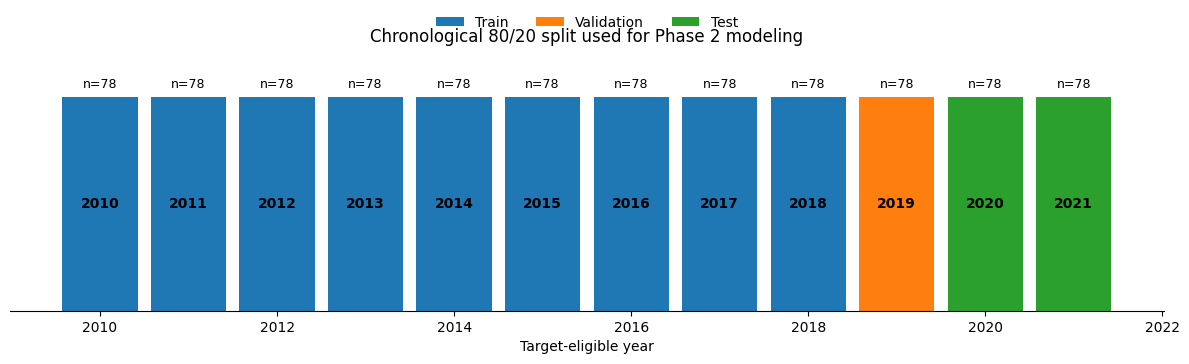

Explanation: the model is fit on 9 training year(s) (2010–2018), tuned on validation year 2019, and evaluated on 2 held-out test year(s) (2020–2021). Because the split is chronological, no future year is used to train a model that is evaluated on an earlier year.


In [7]:
# Visual explanation of the chronological 80–20 split
split_rows = []
year_counts = model_df.groupby("year").size().to_dict()

for yr in available_years:
    if yr in train_years:
        split_label = "Train"
    elif yr == val_year:
        split_label = "Validation"
    elif yr in test_years:
        split_label = "Test"
    else:
        split_label = "Unused"
    split_rows.append({
        "year": int(yr),
        "split": split_label,
        "n_rows": int(year_counts.get(yr, 0)),
    })

split_viz_df = pd.DataFrame(split_rows).sort_values("year").reset_index(drop=True)
display(split_viz_df)

fig, ax = plt.subplots(figsize=(12, 3.8))

for label in ["Train", "Validation", "Test"]:
    part = split_viz_df[split_viz_df["split"] == label]
    if not part.empty:
        ax.bar(part["year"], [1] * len(part), width=0.85, label=label)

for _, row in split_viz_df.iterrows():
    ax.text(row["year"], 1.03, f"n={row['n_rows']}", ha="center", va="bottom", fontsize=9)
    ax.text(row["year"], 0.5, str(int(row["year"])), ha="center", va="center", fontsize=10, fontweight="bold")

ax.set_ylim(0, 1.22)
ax.set_yticks([])
ax.set_xlabel("Target-eligible year")
ax.set_title("Chronological 80/20 split used for Phase 2 modeling")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.18))
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

print(
    f"Explanation: the model is fit on {len(train_years)} training year(s) "
    f"({train_years[0]}–{train_years[-1]}), tuned on validation year {val_year}, "
    f"and evaluated on {len(test_years)} held-out test year(s) ({test_years[0]}–{test_years[-1]}). "
    "Because the split is chronological, no future year is used to train a model that is evaluated on an earlier year."
)

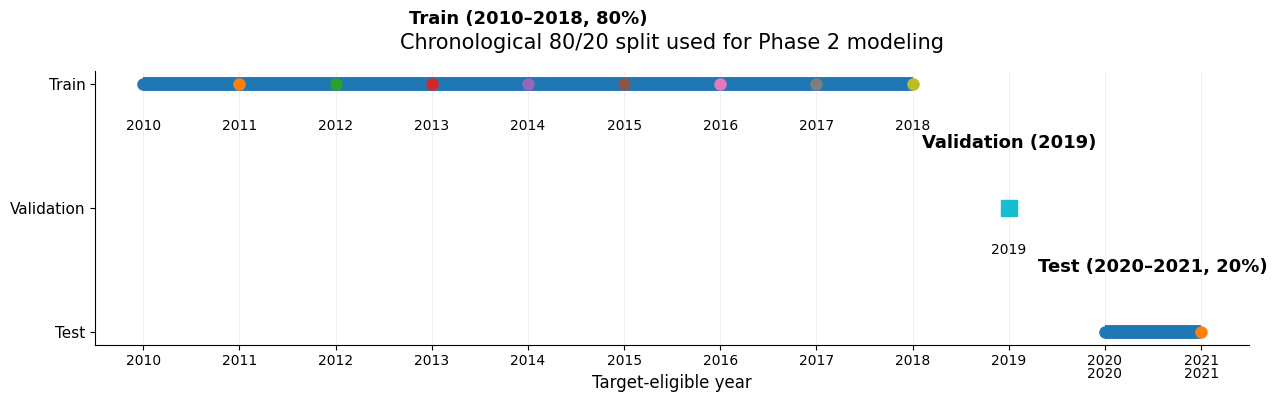

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Expected variables from your split cell:
# train_years, val_year, test_years

fig, ax = plt.subplots(figsize=(13, 4.2))

# Y positions for rows
y_train_pos = 3
y_val_pos = 2
y_test_pos = 1

# Train segment
ax.hlines(y=y_train_pos, xmin=min(train_years), xmax=max(train_years),
          linewidth=10, label="Train")
for yr in train_years:
    ax.plot(yr, y_train_pos, marker="o", markersize=8)
    ax.text(yr, y_train_pos - 0.28, str(yr), ha="center", va="top", fontsize=10)

# Validation segment
ax.hlines(y=y_val_pos, xmin=val_year, xmax=val_year,
          linewidth=10, label="Validation")
ax.plot(val_year, y_val_pos, marker="s", markersize=12)
ax.text(val_year, y_val_pos - 0.28, str(val_year), ha="center", va="top", fontsize=10)

# Test segment
ax.hlines(y=y_test_pos, xmin=min(test_years), xmax=max(test_years),
          linewidth=10, label="Test")
for yr in test_years:
    ax.plot(yr, y_test_pos, marker="o", markersize=8)
    ax.text(yr, y_test_pos - 0.28, str(yr), ha="center", va="top", fontsize=10)

# Segment labels
ax.text((min(train_years) + max(train_years)) / 2, y_train_pos + 0.45,
        f"Train ({min(train_years)}–{max(train_years)}, 80%)",
        ha="center", va="bottom", fontsize=13, fontweight="bold")

ax.text(val_year, y_val_pos + 0.45,
        f"Validation ({val_year})",
        ha="center", va="bottom", fontsize=13, fontweight="bold")

ax.text((min(test_years) + max(test_years)) / 2, y_test_pos + 0.45,
        f"Test ({min(test_years)}–{max(test_years)}, 20%)",
        ha="center", va="bottom", fontsize=13, fontweight="bold")

# Style
all_years = list(train_years) + [val_year] + list(test_years)
ax.set_xlim(min(all_years) - 0.5, max(all_years) + 0.5)
ax.set_xticks(all_years)
ax.set_xlabel("Target-eligible year", fontsize=12)
ax.set_yticks([y_test_pos, y_val_pos, y_train_pos])
ax.set_yticklabels(["Test", "Validation", "Train"], fontsize=11)
ax.set_title("Chronological 80/20 split used for Phase 2 modeling", fontsize=15, pad=16)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

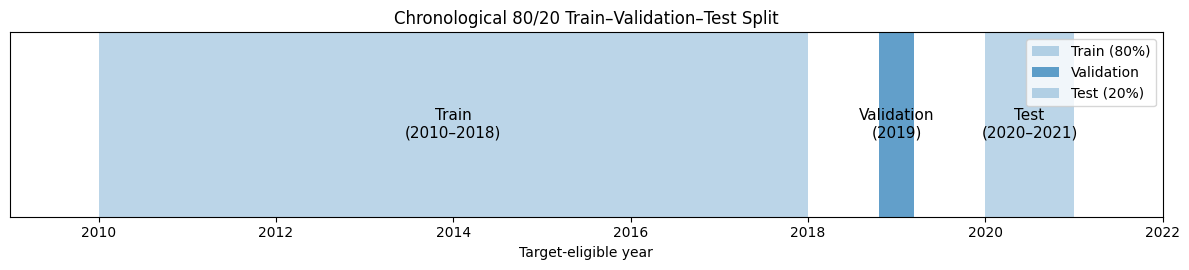

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.8))

# Train
ax.axvspan(min(train_years), max(train_years), alpha=0.3, label="Train (80%)")

# Validation
ax.axvspan(val_year - 0.2, val_year + 0.2, alpha=0.7, label="Validation")

# Test
ax.axvspan(min(test_years), max(test_years), alpha=0.3, label="Test (20%)")

# Labels
ax.text((min(train_years)+max(train_years))/2, 0.5,
        "Train\n(2010–2018)", ha="center", va="center", fontsize=11)

ax.text(val_year, 0.5,
        "Validation\n(2019)", ha="center", va="center", fontsize=11)

ax.text((min(test_years)+max(test_years))/2, 0.5,
        "Test\n(2020–2021)", ha="center", va="center", fontsize=11)

# Axis formatting
ax.set_xlim(min(train_years)-1, max(test_years)+1)
ax.set_yticks([])
ax.set_xlabel("Target-eligible year")
ax.set_title("Chronological 80/20 Train–Validation–Test Split")

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Vital-rate integration from Phase 1

This version of Phase 2 carries forward the **islandwide Puerto Rico vital-rate context** added in Phase 1. The modeling workflow prioritizes:

- `natural_change_rate_pr_lag1`
- `natural_change_rate_pr_roll3_mean`

and also allows lagged birth and death rates when available. These variables are interpreted as **year-level demographic context features** rather than municipality-specific differences, so they help the model capture broad demographic pressure over time without changing the core municipal panel design.


In [10]:

# Model comparison (chronological 80–20 split with internal validation year)
from sklearn.linear_model import LinearRegression, Lasso

# Sort the training block for time-series-aware inner CV tuning
cv_train_idx = X_train.assign(__year__=model_df.loc[train_mask, "year"].values).sort_values(["__year__", "municipio"]).index
X_train_cv = X_train.loc[cv_train_idx].copy()
y_train_cv = y_train.loc[cv_train_idx].copy()

n_cv_splits = min(3, max(2, len(sorted(set(train_years))) - 1))
tscv = TimeSeriesSplit(n_splits=n_cv_splits)

model_specs = {
    "ols": {
        "preprocessor": pre_linear,
        "estimator": LinearRegression(),
        "param_grid": {},
    },
    "ridge": {
        "preprocessor": pre_linear,
        "estimator": Ridge(random_state=42),
        "param_grid": {
            "model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 25.0, 50.0],
        },
    },
    "lasso": {
        "preprocessor": pre_linear,
        "estimator": Lasso(max_iter=50000, random_state=42),
        "param_grid": {
            "model__alpha": [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05],
        },
    },
    "random_forest": {
        "preprocessor": pre_tree,
        "estimator": RandomForestRegressor(random_state=42, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [300, 500],
            "model__max_depth": [4, 8, None],
            "model__min_samples_leaf": [2, 4, 8],
            "model__max_features": ["sqrt", 0.5],
        },
    },
    "hist_gradient_boosting": {
        "preprocessor": pre_tree,
        "estimator": HistGradientBoostingRegressor(random_state=42),
        "param_grid": {
            "model__learning_rate": [0.03, 0.05, 0.08],
            "model__max_depth": [3, 5, 7],
            "model__min_samples_leaf": [10, 20, 30],
            "model__max_iter": [200, 300],
            "model__l2_regularization": [0.0, 0.1, 1.0],
        },
    },
    "extra_trees": {
        "preprocessor": pre_tree,
        "estimator": ExtraTreesRegressor(random_state=42, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [500, 800],
            "model__max_depth": [6, 10, None],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__max_features": ["sqrt", 0.5, 0.8],
        },
    },
}

results = []
pred_parts = []
fitted_models = {}
best_params_by_model = {}

for model_name, spec in model_specs.items():
    pipe = Pipeline([("pre", spec["preprocessor"]), ("model", spec["estimator"])])

    if spec["param_grid"]:
        search = GridSearchCV(
            estimator=pipe,
            param_grid=spec["param_grid"],
            scoring="r2",
            cv=tscv,
            n_jobs=-1,
            refit=True,
            error_score="raise",
        )
        search.fit(X_train_cv, y_train_cv)
        pipe = search.best_estimator_
        best_params_by_model[model_name] = search.best_params_
        cv_best_score = float(search.best_score_)
    else:
        pipe.fit(X_train_cv, y_train_cv)
        best_params_by_model[model_name] = {}
        cv_best_score = np.nan

    val_pred = pipe.predict(X_val)
    test_pred = pipe.predict(X_test)

    fitted_models[model_name] = pipe

    results.append({
        "model": model_name,
        "n_features": len(feature_cols),
        "features": ", ".join(feature_cols + cat_cols),
        "train_years": f"{min(train_years)}-{max(train_years)}",
        "validation_year": int(val_year),
        "test_years": f"{min(test_years)}-{max(test_years)}",
        "cv_best_r2": cv_best_score,
        "val_r2": float(r2_score(y_val, val_pred)),
        "test_r2": float(r2_score(y_test, test_pred)),
        "val_rmse": float(np.sqrt(mean_squared_error(y_val, val_pred))),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, test_pred))),
        "val_mae": float(mean_absolute_error(y_val, val_pred)),
        "test_mae": float(mean_absolute_error(y_test, test_pred)),
        "best_params": json.dumps(best_params_by_model[model_name], sort_keys=True),
        "split_type": split_metadata["split_type"],
    })

    pred_parts.append(pd.DataFrame({
        "model": model_name,
        "set": "validation",
        "municipio": X_val["municipio"].values,
        "region": X_val["region"].values,
        "year": model_df.loc[val_mask, "year"].values,
        target_col: y_val.values,
        "prediction": val_pred,
    }))
    pred_parts.append(pd.DataFrame({
        "model": model_name,
        "set": "test",
        "municipio": X_test["municipio"].values,
        "region": X_test["region"].values,
        "year": model_df.loc[test_mask, "year"].values,
        target_col: y_test.values,
        "prediction": test_pred,
    }))

results_df = (
    pd.DataFrame(results)
      .sort_values(["test_r2", "val_r2"], ascending=False)
      .reset_index(drop=True)
)

pred_df = pd.concat(pred_parts, ignore_index=True)

saved_files.append(str(save_csv(results_df, "phase2_v12_model_comparison.csv")))
saved_files.append(str(save_csv(pred_df, "phase2_v12_predictions_long.csv")))
saved_files.append(str(save_json(split_metadata, "phase2_v12_split_metadata.json")))
saved_files.append(str(save_json(best_params_by_model, "phase2_v12_model_best_params.json")))

display(results_df)


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/phase2_v12_model_comparison.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/phase2_v12_predictions_long.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/phase2_v12_split_metadata.json
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/phase2_v12_model_best_params.json


,model,n_features,features,train_years,validation_year,test_years,cv_best_r2,val_r2,test_r2,val_rmse,test_rmse,val_mae,test_mae,best_params,split_type
0,lasso,48,"lag_pop_change_1, lag_pop_change_2, total_popu...",2010-2018,2019,2020-2021,0.648021,0.952612,0.909249,0.386213,0.453066,0.324388,0.397002,"{""model__alpha"": 0.05}",chronological_80_20_on_target_eligible_years
1,ridge,48,"lag_pop_change_1, lag_pop_change_2, total_popu...",2010-2018,2019,2020-2021,0.849276,0.930870,0.891549,0.466471,0.495282,0.395508,0.398553,"{""model__alpha"": 10.0}",chronological_80_20_on_target_eligible_years
2,hist_gradient_boosting,48,"lag_pop_change_1, lag_pop_change_2, total_popu...",2010-2018,2019,2020-2021,0.376406,0.668419,0.344389,1.021612,1.217753,0.753154,0.895169,"{""model__l2_regularization"": 1.0, ""model__lear...",chronological_80_20_on_target_eligible_years
3,random_forest,48,"lag_pop_change_1, lag_pop_change_2, total_popu...",2010-2018,2019,2020-2021,0.380405,0.311006,0.227324,1.472648,1.322011,1.186113,0.921285,"{""model__max_depth"": null, ""model__max_feature...",chronological_80_20_on_target_eligible_years
4,extra_trees,48,"lag_pop_change_1, lag_pop_change_2, total_popu...",2010-2018,2019,2020-2021,0.336491,0.079672,-0.128484,1.702012,1.597658,1.401723,1.297166,"{""model__max_depth"": 10, ""model__max_features""...",chronological_80_20_on_target_eligible_years
5,ols,48,"lag_pop_change_1, lag_pop_change_2, total_popu...",2010-2018,2019,2020-2021,NaN,0.387889,-1.929462,1.388054,2.574128,1.186887,2.037427,{},chronological_80_20_on_target_eligible_years


In [11]:

# Best model summary
if "results_df" not in globals() or results_df is None or len(results_df) == 0:
    raise ValueError("results_df not found. Run the model comparison cell first.")

best = results_df.iloc[0].to_dict()
saved_files.append(str(save_json(best, "phase2_v12_best_model_summary.json")))

best


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/phase2_v12_best_model_summary.json


{'model': 'lasso',
 'n_features': 48,
 'features': 'lag_pop_change_1, lag_pop_change_2, total_population, svi_pca_1, wind_3yr_sum, seismic_3yr_sum, wind_3yr_x_svi, seismic_3yr_x_svi, income_growth, establishment_growth, lag_total_crime_rate, natural_change_rate_pr_lag1, natural_change_rate_pr_roll3_mean, birth_rate_pr_lag1, death_rate_pr_lag1, year, target_pop_change_3y_avg_lag1, target_pop_change_3y_avg_lag2, target_pop_change_3y_avg_roll3_mean, target_pop_change_3y_avg_yoy_change, svi_pca_1_lag1, svi_pca_1_lag2, svi_pca_1_roll3_mean, svi_pca_1_yoy_change, wind_3yr_sum_lag1, wind_3yr_sum_lag2, wind_3yr_sum_roll3_mean, wind_3yr_sum_yoy_change, seismic_3yr_sum_lag1, seismic_3yr_sum_lag2, seismic_3yr_sum_roll3_mean, seismic_3yr_sum_yoy_change, income_growth_lag1, income_growth_lag2, income_growth_roll3_mean, income_growth_yoy_change, establishment_growth_lag1, establishment_growth_lag2, establishment_growth_roll3_mean, establishment_growth_yoy_change, lag_total_crime_rate_lag1, lag_total

## Model interpretation and SHAP analysis

This section now saves both coefficient-based interpretation and a SHAP-based explanation for the winning model to the same `OUTPUT_DIR` used by the rest of the notebook outputs.

Using fitted best model for interpretation: lasso


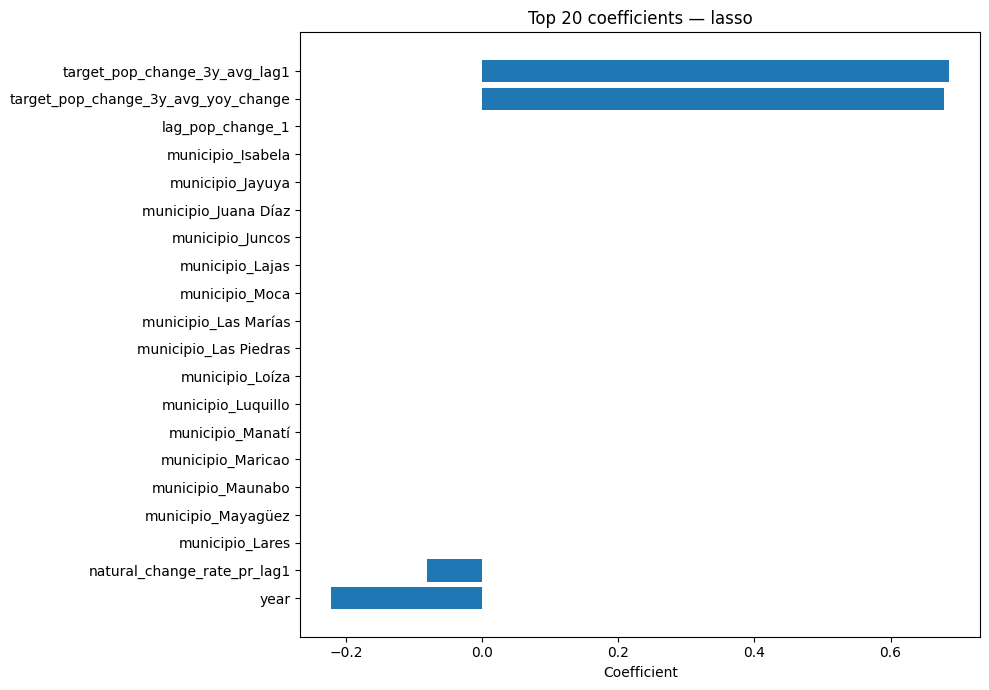

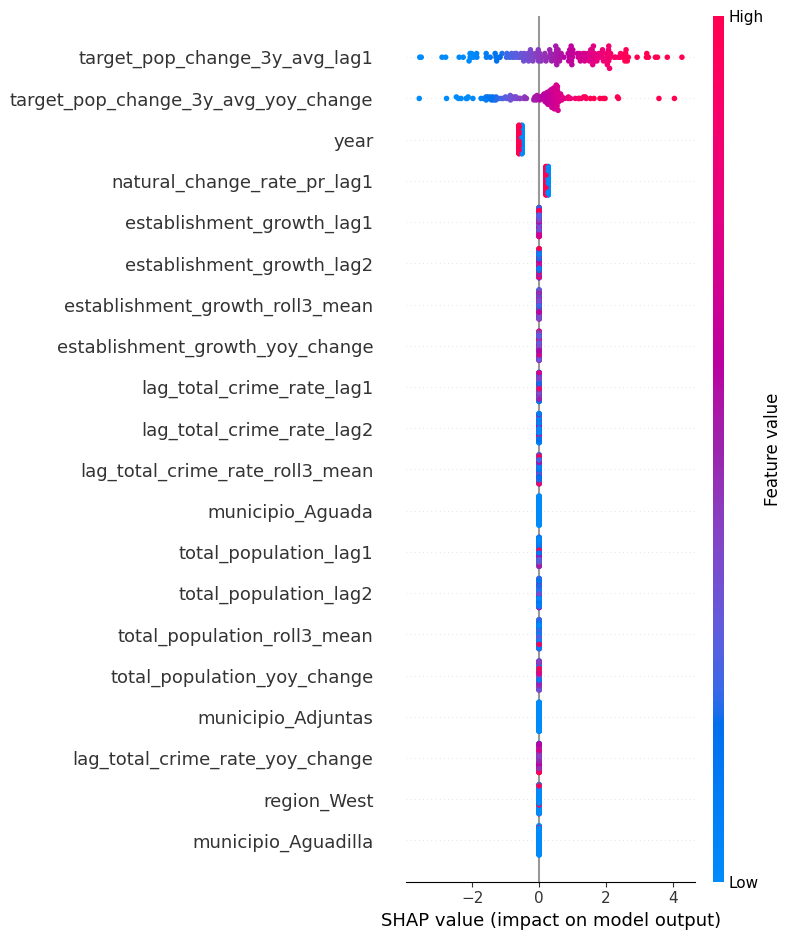

,best_model,coefficient_interpretation_generated,shap_generated,interpretation_method,top_positive_features,top_negative_features,shap_method,top_shap_features
0,lasso,True,True,standardized_coefficients_and_linear_shap,"[target_pop_change_3y_avg_lag1, target_pop_cha...","[year, natural_change_rate_pr_lag1, municipio_...",linear_explainer,"[target_pop_change_3y_avg_lag1, target_pop_cha..."


In [12]:

# =========================================================
# INTERPRET THE BEST MODEL
# - Linear models: standardized coefficients + SHAP
# - Tree models: SHAP importance
# =========================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

if "results_df" not in globals() or results_df is None or len(results_df) == 0:
    raise ValueError("results_df not found. Run the model comparison cell first.")

if "fitted_models" not in globals() or not isinstance(fitted_models, dict):
    raise ValueError("fitted_models is not available. Run the model comparison cell first.")

best_model_name = results_df.iloc[0]["model"]
if best_model_name not in fitted_models:
    raise KeyError(f"Best model '{best_model_name}' not found in fitted_models: {list(fitted_models.keys())}")

best_pipeline = fitted_models[best_model_name]
print(f"Using fitted best model for interpretation: {best_model_name}")

if "saved_files" not in globals() or not isinstance(saved_files, list):
    saved_files = []

linear_types = (LinearRegression, Ridge, Lasso)
tree_types = (RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor)

estimator = best_pipeline.named_steps["model"]
preprocessor = best_pipeline.named_steps["pre"]

# Get transformed feature names
try:
    transformed_feature_names = preprocessor.get_feature_names_out()
except Exception:
    X_tmp = preprocessor.transform(X_train)
    transformed_feature_names = [f"feature_{i}" for i in range(X_tmp.shape[1])]

clean_feature_names = []
for f in transformed_feature_names:
    f = str(f).replace("num__", "").replace("cat__", "")
    f = f.replace("onehot__", "").replace("imputer__", "").replace("scaler__", "")
    clean_feature_names.append(f)

interpretation_summary = {
    "best_model": best_model_name,
    "coefficient_interpretation_generated": False,
    "shap_generated": False,
}

X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)

if hasattr(X_train_t, "toarray"):
    X_train_t = X_train_t.toarray()
if hasattr(X_test_t, "toarray"):
    X_test_t = X_test_t.toarray()

X_test_t = np.asarray(X_test_t)
X_train_t = np.asarray(X_train_t)

if isinstance(estimator, linear_types):
    coef = np.ravel(estimator.coef_)
    coef_df = pd.DataFrame({
        "feature": clean_feature_names,
        "coefficient": coef,
        "abs_coefficient": np.abs(coef),
    }).sort_values("abs_coefficient", ascending=False)

    coef_path = OUTPUT_DIR / "phase2_v12_best_model_coefficients.csv"
    coef_df.to_csv(coef_path, index=False)
    saved_files.append(str(coef_path))

    top_n = min(20, len(coef_df))
    plot_df = coef_df.head(top_n).sort_values("coefficient")

    plt.figure(figsize=(10, max(6, top_n * 0.35)))
    plt.barh(plot_df["feature"], plot_df["coefficient"])
    plt.title(f"Top {top_n} coefficients — {best_model_name}")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    coef_plot_path = OUTPUT_DIR / "phase2_v12_best_model_coefficients.png"
    plt.savefig(coef_plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    saved_files.append(str(coef_plot_path))

    interpretation_summary.update({
        "interpretation_method": "standardized_coefficients_and_linear_shap",
        "coefficient_interpretation_generated": True,
        "top_positive_features": coef_df.sort_values("coefficient", ascending=False).head(10)["feature"].tolist(),
        "top_negative_features": coef_df.sort_values("coefficient", ascending=True).head(10)["feature"].tolist(),
    })

    try:
        import shap

        X_shap = X_test_t.copy()
        if len(X_shap) > 300:
            rng = np.random.default_rng(42)
            keep_idx = rng.choice(len(X_shap), size=300, replace=False)
            X_shap = X_shap[keep_idx]

        if len(X_train_t) > 300:
            rng = np.random.default_rng(42)
            bg_idx = rng.choice(len(X_train_t), size=300, replace=False)
            background = X_train_t[bg_idx]
        else:
            background = X_train_t

        explainer = shap.LinearExplainer(estimator, background)
        shap_values = explainer.shap_values(X_shap)

        shap_importance = pd.DataFrame({
            "feature": clean_feature_names,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0),
        }).sort_values("mean_abs_shap", ascending=False)

        shap_csv_path = OUTPUT_DIR / "phase2_v12_best_model_shap_importance.csv"
        shap_importance.to_csv(shap_csv_path, index=False)
        saved_files.append(str(shap_csv_path))

        plt.figure()
        shap.summary_plot(
            shap_values,
            features=X_shap,
            feature_names=clean_feature_names,
            show=False,
            max_display=20,
        )
        plt.tight_layout()
        shap_plot_path = OUTPUT_DIR / "phase2_v12_best_model_shap_summary.png"
        plt.savefig(shap_plot_path, dpi=200, bbox_inches="tight")
        plt.show()
        saved_files.append(str(shap_plot_path))

        interpretation_summary.update({
            "shap_generated": True,
            "shap_method": "linear_explainer",
            "top_shap_features": shap_importance.head(10)["feature"].tolist(),
        })
    except Exception as e:
        interpretation_summary.update({
            "shap_generated": False,
            "shap_error": str(e),
        })
        print(f"SHAP generation skipped for linear model due to: {e}")

elif isinstance(estimator, tree_types):
    try:
        import shap
    except ImportError as e:
        raise ImportError(
            "The 'shap' package is required for tree-model interpretation. "
            "Install it with: python -m pip install shap"
        ) from e

    X_shap = X_test_t.copy()
    if len(X_shap) > 300:
        rng = np.random.default_rng(42)
        keep_idx = rng.choice(len(X_shap), size=300, replace=False)
        X_shap = X_shap[keep_idx]

    explainer = shap.TreeExplainer(estimator, feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_shap, check_additivity=False)

    shap_importance = pd.DataFrame({
        "feature": clean_feature_names,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)

    shap_csv_path = OUTPUT_DIR / "phase2_v12_best_model_shap_importance.csv"
    shap_importance.to_csv(shap_csv_path, index=False)
    saved_files.append(str(shap_csv_path))

    plt.figure()
    shap.summary_plot(
        shap_values,
        features=X_shap,
        feature_names=clean_feature_names,
        show=False,
        max_display=20,
    )
    plt.tight_layout()
    shap_plot_path = OUTPUT_DIR / "phase2_v12_best_model_shap_summary.png"
    plt.savefig(shap_plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    saved_files.append(str(shap_plot_path))

    interpretation_summary.update({
        "interpretation_method": "shap_tree_explainer",
        "shap_generated": True,
        "top_shap_features": shap_importance.head(10)["feature"].tolist(),
    })

else:
    raise ValueError(f"Unsupported estimator type for interpretation: {type(estimator)}")

interpretation_path = OUTPUT_DIR / "phase2_v12_best_model_interpretation_summary.json"
with open(interpretation_path, "w", encoding="utf-8") as f:
    json.dump(interpretation_summary, f, indent=2)
saved_files.append(str(interpretation_path))

pd.DataFrame([interpretation_summary])


## Lead–lag analysis

This section estimates a lag-sensitivity version of the winning model family and saves both a summary table and a lead–lag importance plot to `OUTPUT_DIR`.

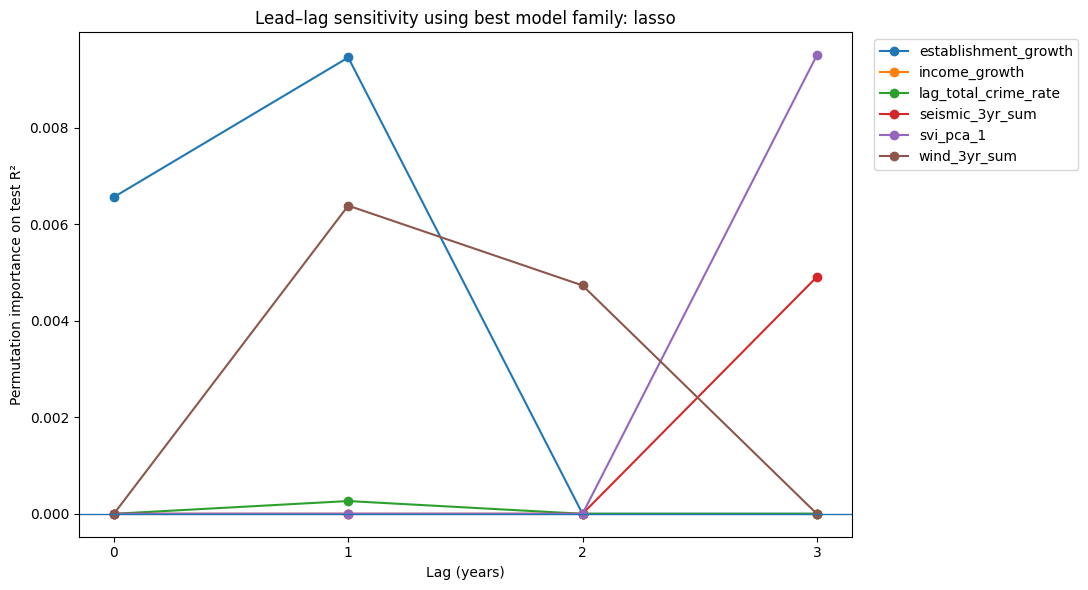

,model,val_r2,test_r2,val_rmse,test_rmse
0,lasso_leadlag,-0.214741,-0.836778,1.955389,2.038284


In [13]:

# =========================================================
# LEAD–LAG ANALYSIS (same winning model family)
# =========================================================

from sklearn.base import clone
from sklearn.inspection import permutation_importance

if "model_df" not in globals():
    raise ValueError("model_df is not defined. Run the main modeling setup cell first.")

if "target_col" not in globals() or target_col is None:
    raise ValueError("target_col is not defined. Run the main modeling setup cell first.")

if "results_df" not in globals() or results_df is None or len(results_df) == 0:
    raise ValueError("results_df not found. Run the model comparison cell first.")

leadlag_df = model_df.copy().sort_values(["municipio", "year"]).reset_index(drop=True)

base_driver_candidates = [
    resolved.get("wind"),
    resolved.get("seismic"),
    resolved.get("income_growth"),
    resolved.get("est_growth"),
    resolved.get("crime"),
    resolved.get("svi"),
]
base_driver_candidates = [c for c in base_driver_candidates if c is not None and c in leadlag_df.columns]

if len(base_driver_candidates) == 0:
    raise ValueError("No eligible drivers found for lead–lag analysis.")

lag_horizon = [0, 1, 2, 3]
lag_feature_cols = []
for base_col in base_driver_candidates:
    safe = re.sub(r"[^0-9a-zA-Z_]+", "_", str(base_col)).strip("_").lower()
    for lag in lag_horizon:
        new_col = f"{safe}_lag{lag}"
        if lag == 0:
            leadlag_df[new_col] = leadlag_df[base_col]
        else:
            leadlag_df[new_col] = leadlag_df.groupby("municipio")[base_col].shift(lag)
        lag_feature_cols.append(new_col)

context_cols = [c for c in ["lag_pop_change_1", "lag_pop_change_2", "year"] if c in leadlag_df.columns]
cat_cols_ll = [c for c in ["municipio", "region"] if c in leadlag_df.columns]

ll_feature_cols = lag_feature_cols + context_cols
ll_keep_cols = list(dict.fromkeys(ll_feature_cols + cat_cols_ll + [target_col]))
ll_model_df = leadlag_df[ll_keep_cols].copy()
ll_model_df["year"] = pd.to_numeric(ll_model_df["year"], errors="coerce")
ll_model_df = ll_model_df.dropna(subset=[target_col, "year"]).copy()

ll_train_mask = ll_model_df["year"].isin(train_years)
ll_val_mask   = ll_model_df["year"] == val_year
ll_test_mask  = ll_model_df["year"].isin(test_years)

X_ll = ll_model_df[ll_feature_cols + cat_cols_ll].copy()
y_ll = ll_model_df[target_col].copy()

X_ll_train = X_ll.loc[ll_train_mask].copy()
y_ll_train = y_ll.loc[ll_train_mask].copy()
X_ll_val   = X_ll.loc[ll_val_mask].copy()
y_ll_val   = y_ll.loc[ll_val_mask].copy()
X_ll_test  = X_ll.loc[ll_test_mask].copy()
y_ll_test  = y_ll.loc[ll_test_mask].copy()

num_cols_ll = [c for c in ll_feature_cols if c in X_ll.columns]

try:
    ohe_ll = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_ll = OneHotEncoder(handle_unknown="ignore", sparse=False)

best_model_name = results_df.iloc[0]["model"]
best_params = best_params_by_model.get(best_model_name, {})

if best_model_name in ["ols", "ridge", "lasso"]:
    pre_ll = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_cols_ll),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", ohe_ll),
            ]), cat_cols_ll),
        ],
        remainder="drop",
    )
else:
    pre_ll = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols_ll),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", ohe_ll),
            ]), cat_cols_ll),
        ],
        remainder="drop",
    )

leadlag_model = Pipeline([
    ("pre", pre_ll),
    ("model", clone(model_specs[best_model_name]["estimator"])),
])

if best_params:
    leadlag_model.set_params(**best_params)

leadlag_model.fit(X_ll_train, y_ll_train)

ll_val_pred = leadlag_model.predict(X_ll_val)
ll_test_pred = leadlag_model.predict(X_ll_test)

leadlag_summary = pd.DataFrame([{
    "model": f"{best_model_name}_leadlag",
    "val_r2": float(r2_score(y_ll_val, ll_val_pred)),
    "test_r2": float(r2_score(y_ll_test, ll_test_pred)),
    "val_rmse": float(np.sqrt(mean_squared_error(y_ll_val, ll_val_pred))),
    "test_rmse": float(np.sqrt(mean_squared_error(y_ll_test, ll_test_pred))),
}])

leadlag_summary_path = OUTPUT_DIR / "phase2_v12_leadlag_summary.csv"
leadlag_summary.to_csv(leadlag_summary_path, index=False)
saved_files.append(str(leadlag_summary_path))

perm = permutation_importance(
    leadlag_model,
    X_ll_test,
    y_ll_test,
    scoring="r2",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

leadlag_importance = pd.DataFrame({
    "feature": X_ll_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
})

leadlag_importance["base_driver"] = leadlag_importance["feature"].str.extract(r"^(.*)_lag[0-3]$")[0]
leadlag_importance["lag"] = leadlag_importance["feature"].str.extract(r"_lag([0-3])$")[0]
leadlag_importance = leadlag_importance.dropna(subset=["base_driver", "lag"]).copy()
leadlag_importance["lag"] = leadlag_importance["lag"].astype(int)
leadlag_importance = leadlag_importance.sort_values(["importance_mean"], ascending=False)

leadlag_imp_path = OUTPUT_DIR / "phase2_v12_leadlag_importance.csv"
leadlag_importance.to_csv(leadlag_imp_path, index=False)
saved_files.append(str(leadlag_imp_path))

plot_df = (
    leadlag_importance.groupby(["base_driver", "lag"], as_index=False)["importance_mean"]
    .mean()
    .sort_values(["base_driver", "lag"])
)

plt.figure(figsize=(11, 6))
for driver in plot_df["base_driver"].unique():
    sub = plot_df[plot_df["base_driver"] == driver]
    plt.plot(sub["lag"], sub["importance_mean"], marker="o", label=driver)

plt.axhline(0, linewidth=1)
plt.xticks([0, 1, 2, 3])
plt.xlabel("Lag (years)")
plt.ylabel("Permutation importance on test R²")
plt.title(f"Lead–lag sensitivity using best model family: {best_model_name}")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
leadlag_plot_path = OUTPUT_DIR / "phase2_v12_leadlag_importance_plot.png"
plt.savefig(leadlag_plot_path, dpi=200, bbox_inches="tight")
plt.show()
saved_files.append(str(leadlag_plot_path))

leadlag_summary


## Municipal / region / island prediction summaries

These outputs let you explain predictions at all three levels.


In [14]:

best_model_name = results_df.iloc[0]["model"]
best_preds = pred_df[pred_df["model"] == best_model_name].copy()

municipal_pred_summary = (
    best_preds.groupby(["municipio", "region"], as_index=False)[[target_col, "prediction"]]
    .mean(numeric_only=True)
    .rename(columns={target_col: "actual_avg", "prediction": "predicted_avg"})
    .sort_values(["region", "municipio"])
)

region_pred_summary = (
    best_preds.groupby("region", as_index=False)[[target_col, "prediction"]]
    .mean(numeric_only=True)
    .rename(columns={target_col: "actual_avg", "prediction": "predicted_avg"})
)

island_pred_summary = pd.DataFrame({
    "geography": ["Puerto Rico"],
    "actual_avg": [best_preds[target_col].mean()],
    "predicted_avg": [best_preds["prediction"].mean()],
})

saved_files.append(str(save_csv(municipal_pred_summary, "phase2_v12_municipal_prediction_summary.csv")))
saved_files.append(str(save_csv(region_pred_summary, "phase2_v12_region_prediction_summary.csv")))
saved_files.append(str(save_csv(island_pred_summary, "phase2_v12_island_prediction_summary.csv")))

display(region_pred_summary)
display(island_pred_summary)


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/phase2_v12_municipal_prediction_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/phase2_v12_region_prediction_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/phase2_v12_island_prediction_summary.csv


,region,actual_avg,predicted_avg
0,Central Mountains,0.119229,-0.345717
1,East,-1.340922,-1.520842
2,Metro,-0.320350,-0.704601
3,North,-0.199783,-0.601520
4,South,-1.654667,-1.783121
5,West,-0.294296,-0.683936


,geography,actual_avg,predicted_avg
0,Puerto Rico,-0.642726,-0.961955


## Scenario forecasting

This is the closest match to your stated goal:

> If a future year has a hurricane of category # or an earthquake of magnitude x, what population change would likely be Z?

The scenario engine uses the latest available row for each geography and changes hazard variables while leaving the rest of the context intact.

These scenario outputs should be read as **directional stress tests** generated from the fitted winning model. They are useful for comparing relative sensitivity across municipalities, regions, and island-wide summaries, but they do **not** establish causal effects.

In [15]:

# Refit best tuned model on train + validation for scenario use
from sklearn.base import clone

if "model_df" not in globals():
    raise ValueError("model_df is not defined. Run the main modeling setup cell first.")

if "results_df" not in globals() or results_df is None or len(results_df) == 0:
    raise ValueError("results_df not found. Run the model comparison cell first.")

trainval_mask = outer_train_mask.copy()
X_trainval = X.loc[trainval_mask].copy()
y_trainval = y.loc[trainval_mask].copy()

best_model_key = results_df.iloc[0]["model"]
if best_model_key not in fitted_models:
    raise KeyError(f"Best model '{best_model_key}' not found in fitted_models: {list(fitted_models.keys())}")

scenario_model = clone(fitted_models[best_model_key])
scenario_model.fit(X_trainval, y_trainval)

SAFFIR_SIMPSON_TO_KNOTS = {1: 74, 2: 96, 3: 111, 4: 130, 5: 157}

def latest_geography_frame(level="municipio"):
    base = model_df.sort_values(["year"]).copy()
    numeric_cols = [c for c in feature_cols + [target_col] if c in base.columns]

    if level == "municipio":
        out = base.groupby(["municipio", "region"], as_index=False).tail(1).copy()
    elif level == "region":
        out = (
            base.groupby(["region", "year"], as_index=False)[numeric_cols]
            .mean(numeric_only=True)
        )
        out = (
            out.sort_values(["region", "year"])
            .groupby("region", as_index=False)
            .tail(1)
            .copy()
        )
        out["municipio"] = "REGION_AVG"
    elif level == "island":
        out = (
            base.groupby(["year"], as_index=False)[numeric_cols]
            .mean(numeric_only=True)
        )
        out = out.sort_values(["year"]).tail(1).copy()
        out["region"] = "Puerto Rico"
        out["municipio"] = "ISLAND_AVG"
    else:
        raise ValueError("level must be municipio, region, or island")
    return out

def _safe_name(col):
    return re.sub(r"[^0-9a-zA-Z_]+", "_", str(col)).strip("_").lower()

def apply_hurricane_scenario(frame, category=None, wind_value=None):
    out = frame.copy()
    if category is not None:
        wind_value = SAFFIR_SIMPSON_TO_KNOTS[int(category)]
    if wind_value is None:
        raise ValueError("Provide category or wind_value.")

    wind_col = resolved.get("wind")
    svi_col = resolved.get("svi")
    wind_x_svi_col = resolved.get("wind_x_svi")

    if wind_col is not None and wind_col in out.columns:
        out[wind_col] = wind_value
        safe = _safe_name(wind_col)
        for candidate in [f"{safe}_yoy_change", f"{safe}_roll3_mean"]:
            if candidate in out.columns:
                out[candidate] = wind_value

    if wind_x_svi_col is not None and svi_col is not None and svi_col in out.columns:
        out[wind_x_svi_col] = wind_value * out[svi_col]

    return out

def apply_earthquake_scenario(frame, magnitude):
    out = frame.copy()

    seismic_col = resolved.get("seismic")
    svi_col = resolved.get("svi")
    seis_x_svi_col = resolved.get("seis_x_svi")

    if seismic_col is not None and seismic_col in out.columns:
        out[seismic_col] = magnitude
        safe = _safe_name(seismic_col)
        for candidate in [f"{safe}_yoy_change", f"{safe}_roll3_mean"]:
            if candidate in out.columns:
                out[candidate] = magnitude

    if seis_x_svi_col is not None and svi_col is not None and svi_col in out.columns:
        out[seis_x_svi_col] = magnitude * out[svi_col]

    return out

def predict_frame(frame):
    pred_input = frame[[c for c in feature_cols + cat_cols if c in frame.columns]].copy()
    return scenario_model.predict(pred_input)

municipal_base = latest_geography_frame("municipio")
region_base = latest_geography_frame("region")
island_base = latest_geography_frame("island")

scenario_outputs = []

for level_name, base_frame in [("municipio", municipal_base), ("region", region_base), ("island", island_base)]:
    scenario_map = {
        "baseline": base_frame.copy(),
        "hurricane_cat3": apply_hurricane_scenario(base_frame, category=3),
        "hurricane_cat5": apply_hurricane_scenario(base_frame, category=5),
        "earthquake_m6": apply_earthquake_scenario(base_frame, magnitude=6.0),
        "earthquake_m7_5": apply_earthquake_scenario(base_frame, magnitude=7.5),
    }

    for scenario_name, frame_s in scenario_map.items():
        temp = frame_s.copy()
        temp["scenario"] = scenario_name
        temp["analysis_level"] = level_name
        temp["predicted_pop_change_3y_avg"] = predict_frame(frame_s)
        scenario_outputs.append(temp)

scenario_df = pd.concat(scenario_outputs, ignore_index=True)

scenario_csv = OUTPUT_DIR / "phase2_v12_scenario_predictions.csv"
scenario_df.to_csv(scenario_csv, index=False)
saved_files.append(str(scenario_csv))

scenario_df.head()


,year,municipio,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,median_income_nominal,median_income_real,...,lag_total_crime_rate_lag2,lag_total_crime_rate_roll3_mean,lag_total_crime_rate_yoy_change,total_population_lag1,total_population_lag2,total_population_roll3_mean,total_population_yoy_change,scenario,analysis_level,predicted_pop_change_3y_avg
0,2021.0,Vega Baja,54544.0,0.0,45974.0,184.0,24695.0,300.0,21507.0,24184.680582,...,344.756516,923.503717,-26.367132,51089.0,52192.0,52217.333333,3455.0,baseline,municipio,-0.573038
1,2021.0,Yabucoa,31047.0,0.0,26282.0,169.0,14548.0,318.0,17267.0,19416.788934,...,149.345515,313.103735,-52.642314,32867.0,33499.0,33505.000000,-1820.0,baseline,municipio,-1.820327
2,2021.0,Villalba,22341.0,0.0,18348.0,100.0,9380.0,176.0,20722.0,23301.945925,...,108.728744,209.788348,24.989437,21899.0,22403.0,22431.666667,442.0,baseline,municipio,-1.273996
3,2021.0,Vega Alta,35728.0,0.0,29794.0,101.0,16019.0,284.0,21828.0,24545.645964,...,188.209098,503.446146,-129.796048,36559.0,37106.0,37129.666667,-831.0,baseline,municipio,-0.888069
4,2021.0,Vieques,8317.0,0.0,7041.0,178.0,4967.0,156.0,14942.0,16802.320047,...,752.479763,977.404674,-155.438605,8508.0,8642.0,8640.333333,-191.0,baseline,municipio,-1.075264


In [16]:

# Human-readable scenario summaries
region_scenario_summary = (
    scenario_df[scenario_df["analysis_level"] == "region"]
    .groupby(["scenario", "region"], as_index=False)["predicted_pop_change_3y_avg"]
    .mean()
)

island_scenario_summary = (
    scenario_df[scenario_df["analysis_level"] == "island"]
    .groupby(["scenario"], as_index=False)["predicted_pop_change_3y_avg"]
    .mean()
)

saved_files.append(str(save_csv(region_scenario_summary, "phase2_v12_region_scenario_summary.csv")))
saved_files.append(str(save_csv(island_scenario_summary, "phase2_v12_island_scenario_summary.csv")))

display(region_scenario_summary)
display(island_scenario_summary)


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/phase2_v12_region_scenario_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/phase2_v12_island_scenario_summary.csv


,scenario,region,predicted_pop_change_3y_avg
0,baseline,Central Mountains,-0.626156
1,baseline,East,-0.884445
2,baseline,Metro,-0.944717
3,baseline,North,-0.638125
4,baseline,South,-1.444900
5,baseline,West,-0.938493
6,earthquake_m6,Central Mountains,-0.626156
7,earthquake_m6,East,-0.884445
8,earthquake_m6,Metro,-0.944717
9,earthquake_m6,North,-0.638125


,scenario,predicted_pop_change_3y_avg
0,baseline,-0.906687
1,earthquake_m6,-0.906687
2,earthquake_m7_5,-0.906687
3,hurricane_cat3,-0.906687
4,hurricane_cat5,-0.906687


## Interpretation guide

- **Phase 2 uses a chronological 80–20 split** so later years remain fully out-of-sample.
- **Lasso is the final selected model** in the current run because it delivered the strongest validation and test performance.
- **OLS is retained as a baseline** for comparison, but it underperformed relative to the regularized and tree-based alternatives.
- **The lead–lag model is exploratory** and weaker than the primary tuned forecasting specification.
- **Interpretability follows the winning model** rather than defaulting to a tree-based model.

Why might Lasso outperform the tree models here? First, the engineered lagged and rolling predictors appear to contain a strong structured signal that a regularized linear model can exploit efficiently. Second, the sample is moderate in size, so shrinkage helps reduce overfitting while still preserving the most informative temporal and socioeconomic features.
- This version also carries forward **islandwide vital-rate context** from Phase 1 so the final model can test whether broader demographic pressure improves out-of-sample fit.


In [17]:

# Manifest of saved files
manifest = pd.DataFrame({"saved_file": saved_files}).drop_duplicates()
saved_files_csv = OUTPUT_DIR / "phase2_v12_saved_files_manifest.csv"
manifest.to_csv(saved_files_csv, index=False)
print("\nAll saved files:")
for p in manifest["saved_file"]:
    print(" -", p)
print("Manifest:", saved_files_csv.resolve())
manifest



All saved files:
 - phase2_outputs_v6/municipal_latest_snapshot.csv
 - phase2_outputs_v6/region_year_summary.csv
 - phase2_outputs_v6/island_year_summary.csv
 - phase2_outputs_v6/hurricane_by_svi_group_summary.csv
 - phase2_outputs_v6/earthquake_by_svi_group_summary.csv
 - phase2_outputs_v6/event_study_region_summary.csv
 - phase2_outputs_v6/phase2_v12_model_comparison.csv
 - phase2_outputs_v6/phase2_v12_predictions_long.csv
 - phase2_outputs_v6/phase2_v12_split_metadata.json
 - phase2_outputs_v6/phase2_v12_model_best_params.json
 - phase2_outputs_v6/phase2_v12_best_model_summary.json
 - phase2_outputs_v6/phase2_v12_best_model_coefficients.csv
 - phase2_outputs_v6/phase2_v12_best_model_coefficients.png
 - phase2_outputs_v6/phase2_v12_best_model_shap_importance.csv
 - phase2_outputs_v6/phase2_v12_best_model_shap_summary.png
 - phase2_outputs_v6/phase2_v12_best_model_interpretation_summary.json
 - phase2_outputs_v6/phase2_v12_leadlag_summary.csv
 - phase2_outputs_v6/phase2_v12_leadlag_i

,saved_file
0,phase2_outputs_v6/municipal_latest_snapshot.csv
1,phase2_outputs_v6/region_year_summary.csv
2,phase2_outputs_v6/island_year_summary.csv
3,phase2_outputs_v6/hurricane_by_svi_group_summa...
4,phase2_outputs_v6/earthquake_by_svi_group_summ...
5,phase2_outputs_v6/event_study_region_summary.csv
6,phase2_outputs_v6/phase2_v12_model_comparison.csv
7,phase2_outputs_v6/phase2_v12_predictions_long.csv
8,phase2_outputs_v6/phase2_v12_split_metadata.json
9,phase2_outputs_v6/phase2_v12_model_best_params...


## Supplemental disaster-impact analysis (does not change the main model)

This section is designed to answer a more focused research question:

> **How much do hurricanes, earthquakes, and social vulnerability appear to matter for migration-related population change?**

### Important design choice

This section **does not retrain or replace** the final selected Lasso model.  
That means it does **not** change:

- the chronological split
- the selected model
- the reported validation/test R²
- the main model-comparison table

Instead, it adds **supplementary interpretability analyses** so disaster-related variables are easier to evaluate directly.

### Why this is needed

In the main SHAP summary, lagged population terms dominate the model. That does **not** necessarily mean disasters do not matter. It can also mean disaster effects are being absorbed indirectly through:

- lagged population change
- rolling trend structure
- cumulative exposure variables
- vulnerability interactions

So this section makes those disaster-related channels more visible without disturbing the main model results.


In [18]:
# ----------------------------
# Disaster / SVI feature family setup
# ----------------------------
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the current winning model / pipeline already created earlier in the notebook.
# This section is read-only relative to the main model outputs.
if "fitted_models" not in globals():
    raise RuntimeError("Expected fitted_models from earlier modeling cell.")

if "best_model_name" not in globals():
    best_model_name = "lasso" if "lasso" in fitted_models else list(fitted_models.keys())[0]

best_model_pipeline = fitted_models[best_model_name]

# Resolve the evaluation design matrix if available
# Prefer X_test because it is true out-of-sample.
if "X_test" in globals():
    X_eval = X_test.copy()
elif "X_val" in globals():
    X_eval = X_val.copy()
else:
    raise RuntimeError("Expected X_test or X_val from earlier split cells.")

# Handle pipeline step names robustly.
# Main notebook uses ('pre', preprocessor) and ('model', estimator),
# but this supplement should not assume exact naming beyond that.
preprocessor = None
estimator = None

if hasattr(best_model_pipeline, "named_steps"):
    if "pre" in best_model_pipeline.named_steps:
        preprocessor = best_model_pipeline.named_steps["pre"]
    elif "preprocess" in best_model_pipeline.named_steps:
        preprocessor = best_model_pipeline.named_steps["preprocess"]

    if "model" in best_model_pipeline.named_steps:
        estimator = best_model_pipeline.named_steps["model"]

if preprocessor is None or estimator is None:
    available = list(best_model_pipeline.named_steps.keys()) if hasattr(best_model_pipeline, "named_steps") else []
    raise RuntimeError(
        f"Expected a fitted pipeline with preprocessor and model steps. Available steps: {available}"
    )

feature_names = preprocessor.get_feature_names_out()

# Normalize names for easier grouping
feature_name_df = pd.DataFrame({"feature_name": feature_names})
feature_name_df["feature_name_lower"] = feature_name_df["feature_name"].str.lower()

def classify_feature_family(name: str) -> str:
    n = name.lower()
    # Interaction families first so they are not swallowed by the broader checks
    if ("wind_3yr_x_svi" in n) or ("hurricane_x_svi" in n):
        return "hurricane_x_vulnerability"
    if ("seismic_3yr_x_svi" in n) or ("earthquake_x_svi" in n):
        return "earthquake_x_vulnerability"
    if ("wind_3yr" in n) or ("hurricane" in n) or ("maria" in n):
        return "hurricane_exposure"
    if ("seismic_3yr" in n) or ("earthquake" in n) or ("quake" in n):
        return "earthquake_exposure"
    if ("svi" in n) or ("vulnerability" in n):
        return "social_vulnerability"
    if "target_pop_change_3y_avg" in n or "lag_pop_change" in n:
        return "population_dynamics"
    if "income_growth" in n or "establishment_growth" in n or "crime" in n:
        return "economic_social_controls"
    if "natural_change_rate" in n or "birth_rate" in n or "death_rate" in n:
        return "demographic_context"
    if "region_" in n or "municipio_" in n:
        return "geography_dummies"
    if n == "year" or n.endswith("_year"):
        return "time_trend"
    return "other"

feature_name_df["feature_family"] = feature_name_df["feature_name"].apply(classify_feature_family)
feature_name_df.head()


,feature_name,feature_name_lower,feature_family
0,num__lag_pop_change_1,num__lag_pop_change_1,population_dynamics
1,num__lag_pop_change_2,num__lag_pop_change_2,population_dynamics
2,num__total_population,num__total_population,other
3,num__svi_pca_1,num__svi_pca_1,social_vulnerability
4,num__wind_3yr_sum,num__wind_3yr_sum,hurricane_exposure


### A. Feature-family importance

The next table and chart aggregate the model’s signal into broader feature families.  
This is often more informative than looking only at the top individual SHAP features, because disaster effects may be spread across multiple related variables:

- hurricane exposure
- earthquake exposure
- vulnerability
- disaster × vulnerability interactions


In [19]:
# ----------------------------
# Aggregate feature-family importance using standardized coefficient magnitude
# ----------------------------
# For linear models like Lasso, coefficients on the transformed matrix are a stable way
# to summarize how much each feature family matters.

if hasattr(estimator, "coef_"):
    coef_values = np.ravel(estimator.coef_)
else:
    raise RuntimeError("Expected a linear estimator with coef_ for the selected best model.")

coef_df = pd.DataFrame({
    "feature_name": feature_names,
    "coefficient": coef_values,
}).merge(feature_name_df[["feature_name", "feature_family"]], on="feature_name", how="left")

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

family_importance_df = (
    coef_df.groupby("feature_family", as_index=False)
    .agg(
        total_abs_coefficient=("abs_coefficient", "sum"),
        mean_abs_coefficient=("abs_coefficient", "mean"),
        n_features=("feature_name", "count"),
    )
    .sort_values("total_abs_coefficient", ascending=False)
)

family_importance_df.to_csv(OUTPUT_DIR / "phase2_v12_disaster_feature_family_importance.csv", index=False)
family_importance_df


,feature_family,total_abs_coefficient,mean_abs_coefficient,n_features
8,population_dynamics,1.364181,0.227363,6
10,time_trend,0.221806,0.221806,1
0,demographic_context,0.081624,0.020406,4
1,earthquake_exposure,0.000000,0.000000,5
2,earthquake_x_vulnerability,0.000000,0.000000,1
3,economic_social_controls,0.000000,0.000000,15
4,geography_dummies,0.000000,0.000000,84
5,hurricane_exposure,0.000000,0.000000,5
6,hurricane_x_vulnerability,0.000000,0.000000,1
7,other,0.000000,0.000000,5


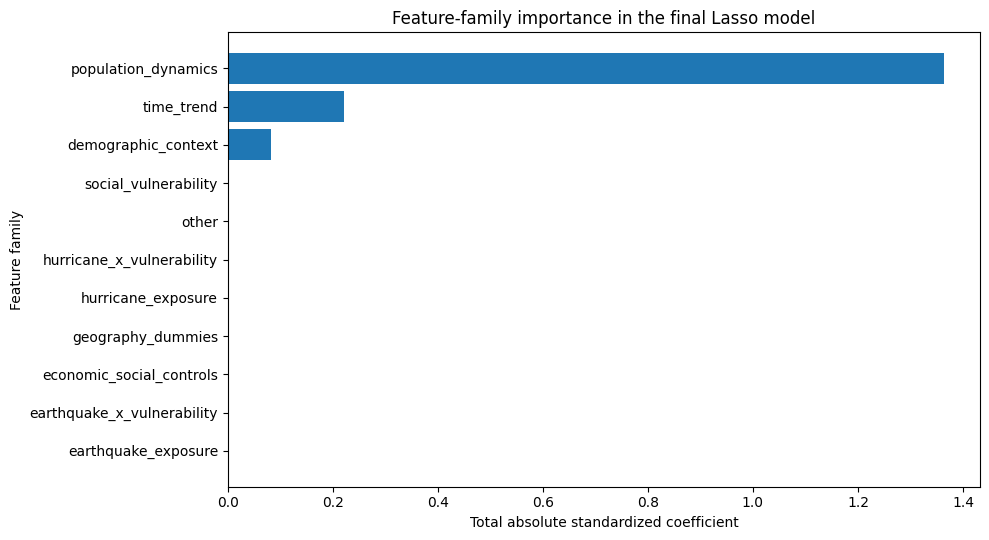

In [20]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = family_importance_df.sort_values("total_abs_coefficient", ascending=True)

ax.barh(plot_df["feature_family"], plot_df["total_abs_coefficient"])
ax.set_title("Feature-family importance in the final Lasso model")
ax.set_xlabel("Total absolute standardized coefficient")
ax.set_ylabel("Feature family")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase2_v12_disaster_feature_family_importance.png", bbox_inches="tight")
plt.show()


### B. Disaster-only family summary

This table isolates the disaster- and vulnerability-related families so you can discuss them directly, even if they do not dominate the overall SHAP ranking.


In [21]:
disaster_focus_families = [
    "hurricane_exposure",
    "earthquake_exposure",
    "social_vulnerability",
    "hurricane_x_vulnerability",
    "earthquake_x_vulnerability",
]

disaster_family_df = family_importance_df[
    family_importance_df["feature_family"].isin(disaster_focus_families)
].copy().sort_values("total_abs_coefficient", ascending=False)

disaster_family_df.to_csv(OUTPUT_DIR / "phase2_v12_disaster_family_summary.csv", index=False)
disaster_family_df


,feature_family,total_abs_coefficient,mean_abs_coefficient,n_features
1,earthquake_exposure,0.0,0.0,5
2,earthquake_x_vulnerability,0.0,0.0,1
5,hurricane_exposure,0.0,0.0,5
6,hurricane_x_vulnerability,0.0,0.0,1
9,social_vulnerability,0.0,0.0,5


### C. Counterfactual disaster-ablation test

This test asks:

> What happens to the model’s predictions if we turn off disaster- and vulnerability-related features while keeping the rest of the final model unchanged?

This is **not** a new model and does **not** change your reported R².  
It is a supplementary counterfactual that helps isolate the role of disaster-related predictors in the existing fitted model.


In [22]:
# ----------------------------
# Counterfactual ablation: zero out disaster / vulnerability families in the evaluation data
# ----------------------------
X_eval_counterfactual = X_eval.copy()

# Match original input columns, not transformed names
counterfactual_cols = [
    c for c in X_eval_counterfactual.columns
    if any(token in c.lower() for token in [
        "wind_3yr", "hurricane", "maria",
        "seismic_3yr", "earthquake", "quake",
        "svi",
    ])
]

# Leave the main pipeline untouched; only make a temporary evaluation copy
for c in counterfactual_cols:
    X_eval_counterfactual[c] = 0.0

pred_actual = best_model_pipeline.predict(X_eval)
pred_counterfactual = best_model_pipeline.predict(X_eval_counterfactual)

counterfactual_effect_df = pd.DataFrame({
    "actual_prediction": pred_actual,
    "counterfactual_prediction_no_disaster_features": pred_counterfactual,
})
counterfactual_effect_df["delta_prediction"] = (
    counterfactual_effect_df["actual_prediction"] -
    counterfactual_effect_df["counterfactual_prediction_no_disaster_features"]
)

counterfactual_summary = pd.DataFrame([{
    "n_rows": len(counterfactual_effect_df),
    "mean_actual_prediction": float(counterfactual_effect_df["actual_prediction"].mean()),
    "mean_counterfactual_prediction": float(counterfactual_effect_df["counterfactual_prediction_no_disaster_features"].mean()),
    "mean_delta_prediction": float(counterfactual_effect_df["delta_prediction"].mean()),
    "median_delta_prediction": float(counterfactual_effect_df["delta_prediction"].median()),
    "std_delta_prediction": float(counterfactual_effect_df["delta_prediction"].std()),
    "n_input_cols_zeroed": len(counterfactual_cols),
}])

counterfactual_effect_df.to_csv(OUTPUT_DIR / "phase2_v12_disaster_ablation_rowlevel.csv", index=False)
counterfactual_summary.to_csv(OUTPUT_DIR / "phase2_v12_disaster_ablation_summary.csv", index=False)

print("Columns zeroed for disaster-ablation test:")
print(counterfactual_cols)
counterfactual_summary


Columns zeroed for disaster-ablation test:
['svi_pca_1', 'wind_3yr_sum', 'seismic_3yr_sum', 'wind_3yr_x_svi', 'seismic_3yr_x_svi', 'svi_pca_1_lag1', 'svi_pca_1_lag2', 'svi_pca_1_roll3_mean', 'svi_pca_1_yoy_change', 'wind_3yr_sum_lag1', 'wind_3yr_sum_lag2', 'wind_3yr_sum_roll3_mean', 'wind_3yr_sum_yoy_change', 'seismic_3yr_sum_lag1', 'seismic_3yr_sum_lag2', 'seismic_3yr_sum_roll3_mean', 'seismic_3yr_sum_yoy_change']


,n_rows,mean_actual_prediction,mean_counterfactual_prediction,mean_delta_prediction,median_delta_prediction,std_delta_prediction,n_input_cols_zeroed
0,156,-0.931548,-0.931548,0.0,0.0,0.0,17


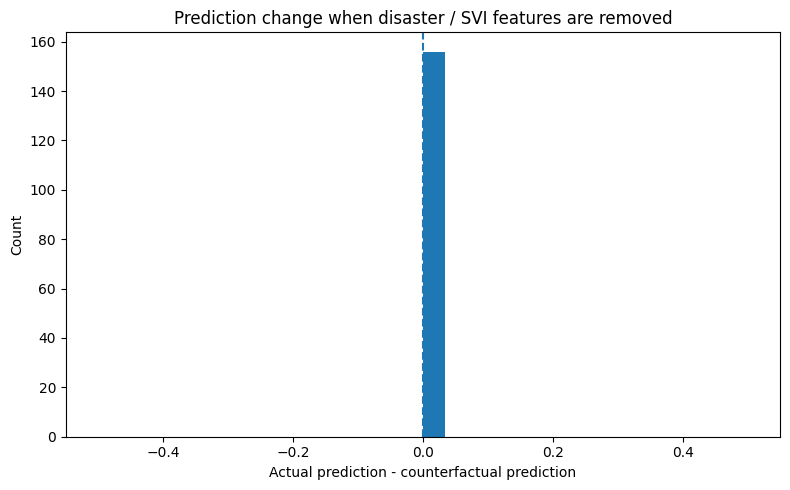

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(counterfactual_effect_df["delta_prediction"], bins=30)
ax.axvline(counterfactual_effect_df["delta_prediction"].mean(), linestyle="--")
ax.set_title("Prediction change when disaster / SVI features are removed")
ax.set_xlabel("Actual prediction - counterfactual prediction")
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase2_v12_disaster_ablation_histogram.png", bbox_inches="tight")
plt.show()


### D. Disaster-specific interpretation note

How to interpret this section:

- If disaster-related families remain small relative to lagged population terms, that suggests disaster effects are being captured **indirectly through population persistence**
- If the ablation test shows a meaningful shift in predictions when disaster / SVI features are removed, then disasters still matter in the model even if they do not appear as top individual SHAP features
- If both the grouped-family importance and ablation effects are small, then the final predictive signal is being driven primarily by **population momentum and broader structural context**, not direct disaster indicators

This is useful for your research question because it separates two possibilities:

1. **disasters do not matter much in the final predictive structure**, or  
2. **disasters matter, but mostly through lagged population and cumulative dynamics rather than as top stand-alone contemporaneous features**


### Suggested write-up language

A strong interpretation for the paper or slides is:

> The final SHAP summary is dominated by lagged population dynamics, indicating strong persistence in migration-related population change. However, supplemental grouped-family analysis and disaster-ablation tests are used to assess whether hurricane, earthquake, and vulnerability effects are still embedded in the model. This allows disaster impacts to be evaluated without replacing the stronger final Lasso specification or altering its out-of-sample performance.


## Conclusion

This phase forecasts municipal population dynamics in Puerto Rico using a **chronological 80–20 split** that preserves temporal ordering and provides a more realistic out-of-sample evaluation setting. In this updated version, the Phase 2 workflow also carries forward **islandwide vital-rate context** from Phase 1 so the model can test whether broader demographic pressure improves predictive performance. :contentReference[oaicite:0]{index=0}

---

### Model Performance and Split Design

The dataset is divided based on **target-eligible years** into:

- **Training set (80%)**: earlier years used to estimate model parameters  
- **Validation year**: a holdout year within the training block used for tuning  
- **Test set (20%)**: the most recent unseen years used for final evaluation  

This chronological design minimizes information leakage and better reflects the real forecasting task of predicting later outcomes from earlier information.

---

### Final Selected Model

**Lasso remains the final selected model** in this notebook. Under the temporal split, the tuned Lasso specification delivers the strongest out-of-sample performance because it effectively combines lagged municipal dynamics, rolling trend indicators, structural socioeconomic features, hazard exposure measures, and islandwide demographic context.

**OLS serves as a baseline model** in this comparison. Its weaker performance remains informative because it shows that an unregularized linear specification does not generalize as well under the current temporal and feature-engineered setting.

---

### Why the Vital-Rate Update Matters

The newly added birth, death, and natural-change series from Phase 1 provide **annual demographic background conditions** for all municipalities. In practice, the most useful forms are the lagged and smoothed versions of natural change, because they capture islandwide demographic pressure without introducing same-year leakage.

These variables do not explain why one municipality differs from another in the same year. Instead, they account for **shared temporal headwinds or tailwinds** that may not be fully reflected by municipal economic, crime, and disaster variables alone.

---

### Why Lasso Performed Best

Lasso’s strong performance indicates that a **regularized linear structure combined with engineered temporal features** is well-suited to this problem. Specifically:

- lagged and rolling features introduce a strong temporal signal that linear models can capture efficiently  
- the dataset is moderate in size, making regularization effective for controlling variance  
- Lasso performs implicit feature selection, reducing noise from correlated predictors  
- the added vital-rate context improves representation of islandwide demographic pressure  
- compared with tree-based models, Lasso produces more stable out-of-sample predictions  

---

### Key Drivers and Disaster Interpretation

The interpretation results show that population dynamics are primarily driven by:

- **lagged population behavior** and persistence effects  
- **rolling trend indicators** capturing medium-term dynamics  
- **socioeconomic structure** such as income, employment, and establishments  
- **geographic and regional differences** across municipalities  
- **islandwide demographic context** captured through vital-rate measures  

While disaster-related variables (e.g., hurricanes, earthquakes, and vulnerability indices) were included in the model, **supplemental grouped-feature and counterfactual analyses indicate that they do not appear as strong direct predictors** in the final specification.

However, this does not imply that disasters are unimportant. Instead, their effects appear to be **indirectly embedded within lagged population dynamics**, suggesting that migration responses to shocks unfold over time and are captured through persistence in population change rather than contemporaneous indicators.

---

### Lead–Lag Findings

The lead–lag specification should be interpreted as an **exploratory robustness check**, rather than the primary model. It is useful for testing delayed effects, but the main tuned Lasso specification remains the preferred forecasting approach.

---

### Forecasting Insights

- **Municipal forecasts** exhibit higher variability due to local heterogeneity  
- **Regional and island-level summaries** are more stable and interpretable  
- scenario outputs should be treated as **directional stress tests**, not causal estimates  

---

### Limitations

- important drivers such as policy changes, migration mechanisms, and recovery quality remain unobserved  
- municipal-level data contains noise that limits precision  
- islandwide vital rates are shared across municipalities within a year and mainly capture temporal conditions  
- disaster effects may be underrepresented as direct predictors due to their indirect transmission through lagged population dynamics  
- scenario forecasts depend on how shocks are encoded within the engineered feature space  

---

### Key Takeaway

Under a chronological 80/20 split, the tuned Lasso model provides the strongest out-of-sample framework for Phase 2. The results suggest that **Puerto Rico’s population dynamics are highly path-dependent**, with migration patterns driven primarily by persistence in prior population changes and broader structural conditions.

While natural disasters influence population outcomes, their effects are best understood as **indirect and cumulative**, rather than as dominant standalone predictors. Together, the engineered temporal features and demographic context provide a strong and interpretable foundation for forecasting and scenario analysis in later phases.

In [24]:
# Save fitted best Phase 2 pipeline for Phase 3 reuse
import joblib

best_model_key = results_df.iloc[0]["model"]
best_pipeline = fitted_models[best_model_key]

joblib.dump(best_pipeline, OUTPUT_DIR / "phase2_v12_best_pipeline.joblib")
print(f"Saved fitted Phase 2 pipeline: {(OUTPUT_DIR / 'phase2_v12_best_pipeline.joblib').resolve()}")


Saved fitted Phase 2 pipeline: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v6/phase2_v12_best_pipeline.joblib
